# Geocoding and Spatial Joins
**Dr. Dave Wanik - University of Connecticut**

Given a town and street address, can I find the lat/lon coordinates and the zip code?

--------------------------------------------------------

In [1]:
# order matters due to installation dependencies
!pip install pandas fiona shapely pyproj rtree geopandas geopy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 535.2/535.2 kB 7.2 MB/s eta 0:00:00


First, we will go from (boring) address strings to lat/lon coordinates - which will unleash a *whole mess* of exciting analytics to pursue.

<center>

![geocoding](https://assets-global.website-files.com/5debb9b4f88fbc3f702d579e/5e08f392743608c081e15e27_e0253d8e4a2f4ebf99c51fb61129cb57.png)

</center>

For example, we can identify which neighborhoods or zip codes our data lies in.

<center>

![zip codes](https://action-lab.org/youth-sports/files/2019/12/2019-12-04-18_58_09-Hartford-Zip-Code-Map-Showing-Neighborhoods-and-Streets.png)

</center>

If this info wasn't provided in a .csv file to you, then you would be toast! I'm going to show you how to make all of this come to life.

In [2]:
!pip install ipython-autotime
%load_ext autotime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 9.5 MB/s eta 0:00:00
time: 312 µs (started: 2024-03-06 15:31:17 +00:00)


In [3]:
# these are three standard Python libraries for data viz and wrangling
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

time: 515 ms (started: 2024-03-06 15:31:17 +00:00)


In [4]:
# geopandas is a GIS version of pandas - perfect for spatial data analysis
import geopandas as gpd
import geopy

time: 821 ms (started: 2024-03-06 15:31:22 +00:00)


In [5]:
# geopy
!pip install geopy


time: 8.96 s (started: 2024-03-06 15:31:26 +00:00)


# Download data

In [6]:
# https://drive.google.com/file/d/1gj3O_hSUDHJhCkWQSeadoHACLfxan3Iz/view?usp=sharing
!gdown 1gj3O_hSUDHJhCkWQSeadoHACLfxan3Iz

Downloading...
From: https://drive.google.com/uc?id=1gj3O_hSUDHJhCkWQSeadoHACLfxan3Iz
To: /content/Real_Estate_Sales_2014-2016.csv
100% 15.4M/15.4M [00:00<00:00, 87.4MB/s]
time: 6.34 s (started: 2024-03-06 15:31:43 +00:00)


# Real Estate Transactions (points)
Here is a static output from a database with house values for properties all around CT.

In [7]:
realEstate = pd.read_csv('/content/Real_Estate_Sales_2014-2016.csv')

time: 350 ms (started: 2024-03-06 15:31:50 +00:00)


In [8]:
realEstate.head()

,ID,SerialNumber,ListYear,DateRecorded,Town,Address,AssessedValue,SaleAmount,SalesRatio,PropertyType,ResidentialType
0,1,14046,2014,9/29/2015,Andover,US ROUTE 6 M 33 B 36 L 22,10720,75000.0,0.142933,Vacant Land,NaN
1,2,14011,2014,1/14/2015,Andover,1 JUROVATY LANE,153100,190000.0,0.805789,Residential,Single Family
2,3,15006,2015,11/30/2015,Andover,1 ROSE LANE,102900,50000.0,2.058000,Residential,Single Family
3,4,14044,2014,9/28/2015,Andover,10 PINE RIDGE DR,108700,128368.0,0.846784,Residential,Single Family
4,5,14035,2014,8/10/2015,Andover,101 WALES RD,164000,230000.0,0.713043,Residential,Single Family


time: 31.7 ms (started: 2024-03-06 15:31:51 +00:00)


In [9]:
realEstate.shape #145K rows

(145987, 11)

time: 3.42 ms (started: 2024-03-06 15:32:41 +00:00)


### Concatenate
Let's make the address ONE field.

In [10]:
# make one string
realEstate['oneAddress'] = realEstate['Address'] + ' ' + realEstate['Town'] + ' ' + 'CT'
realEstate.head()

,ID,SerialNumber,ListYear,DateRecorded,Town,Address,AssessedValue,SaleAmount,SalesRatio,PropertyType,ResidentialType,oneAddress
0,1,14046,2014,9/29/2015,Andover,US ROUTE 6 M 33 B 36 L 22,10720,75000.0,0.142933,Vacant Land,NaN,US ROUTE 6 M 33 B 36 L 22 Andover CT
1,2,14011,2014,1/14/2015,Andover,1 JUROVATY LANE,153100,190000.0,0.805789,Residential,Single Family,1 JUROVATY LANE Andover CT
2,3,15006,2015,11/30/2015,Andover,1 ROSE LANE,102900,50000.0,2.058000,Residential,Single Family,1 ROSE LANE Andover CT
3,4,14044,2014,9/28/2015,Andover,10 PINE RIDGE DR,108700,128368.0,0.846784,Residential,Single Family,10 PINE RIDGE DR Andover CT
4,5,14035,2014,8/10/2015,Andover,101 WALES RD,164000,230000.0,0.713043,Residential,Single Family,101 WALES RD Andover CT


time: 160 ms (started: 2024-03-06 15:32:52 +00:00)


# Geocoding
Warning: this script will take time! Maybe only pick 30 rows (will take 30 seconds to run!).

We can pre-load an already run dataset to save time.

Pay attention to 'Nominatim' - this is the free geocoder we are using via an API.
* https://pypi.org/project/geopy/

If this one gives you issues (it happens!), try this new one:
* https://geocoder.readthedocs.io/

In [11]:
# sample 30, 100 or 1000 rows depending on geocoder time
df = realEstate.sample(n=30, axis=0, random_state=123)
print(df.shape)
df.head()

(30, 12)


,ID,SerialNumber,ListYear,DateRecorded,Town,Address,AssessedValue,SaleAmount,SalesRatio,PropertyType,ResidentialType,oneAddress
53330,53331,15045,2015,5/26/2016,Lisbon,26 GRAHAM TERRACE,112970,145000.0,0.779103,Residential,Single Family,26 GRAHAM TERRACE Lisbon CT
6239,6240,160277,2016,4/3/2017,Branford,12 TOOLE DR,181200,240000.0,0.755000,Residential,Single Family,12 TOOLE DR Branford CT
82344,82345,151554,2015,9/21/2016,Norwalk,16 ROCKMEADOW RD UNIT X,151660,230000.0,0.659391,Residential,Single Family,16 ROCKMEADOW RD UNIT X Norwalk CT
83513,83514,161303,2016,8/8/2017,Norwalk,31 STARLIGHT DR,321650,405000.0,0.794198,Residential,Single Family,31 STARLIGHT DR Norwalk CT
112515,112516,140797,2014,4/7/2015,Stamford,9 ETHAN ALLEN LANE,480800,840000.0,0.572381,Residential,Single Family,9 ETHAN ALLEN LANE Stamford CT


time: 65.2 ms (started: 2024-03-06 15:33:14 +00:00)


**NOTE:** the geocoder will take 20 minutes for 1000 records on Colab Pro!!! Uncomment out and try to run if you would like to.

In [ ]:

# from geopy.geocoders import Nominatim # this is the geocoder, Nominatim
# # there are other apps you can use!
# # https://pypi.org/project/geopy/

# locator = Nominatim(user_agent='myGeocoder')

# from geopy.extra.rate_limiter import RateLimiter

# # 1 - conveneint function to delay between geocoding calls

# geocode = RateLimiter(locator.geocode, min_delay_seconds=1)

# # 2- - create location column

# df['location'] = df['oneAddress'].apply(geocode)

# # 3 - create longitude, laatitude and altitude from location column (returns tuple)

# df['point'] = df['location'].apply(lambda loc: tuple(loc.point) if loc else None)

# # 4 - split point column into latitude, longitude and altitude columns

# df[['latitude', 'longitude', 'altitude']] = pd.DataFrame(df['point'].tolist(), index=df.index)

Check the shape to see how much might have dropped off.

Save your work - 1000 rows is a lot of time!

In [12]:
# https://drive.google.com/file/d/19YSvlVBe3JCYifCPD6a0m2fE4bm6zlbh/view?usp=sharing
!gdown 19YSvlVBe3JCYifCPD6a0m2fE4bm6zlbh

Downloading...
From: https://drive.google.com/uc?id=19YSvlVBe3JCYifCPD6a0m2fE4bm6zlbh
To: /content/latlon_Real_Estate_Sales_2014-2016.csv
100% 238k/238k [00:00<00:00, 69.7MB/s]
time: 1.51 s (started: 2024-03-06 15:34:04 +00:00)


In [ ]:
# df.to_csv('latlon_Real_Estate_Sales_2014-2016.csv')

time: 6.68 ms (started: 2024-02-29 21:12:08 +00:00)


For brevity, I've already created this for you! You can just read it in to save time.

In [13]:
df = pd.read_csv('/content/latlon_Real_Estate_Sales_2014-2016.csv')
df.head()

,Unnamed: 0,ID,SerialNumber,ListYear,DateRecorded,Town,Address,AssessedValue,SaleAmount,SalesRatio,PropertyType,ResidentialType,oneAddress,location,point,latitude,longitude,altitude
0,53330,53331,15045,2015,5/26/2016,Lisbon,26 GRAHAM TERRACE,112970,145000.0,0.779103,Residential,Single Family,26 GRAHAM TERRACE Lisbon CT,"26, Graham Terrace, Lisbon, New London County,...","(41.56667285661604, -72.04098572186558, 0.0)",41.566673,-72.040986,0.0
1,6239,6240,160277,2016,4/3/2017,Branford,12 TOOLE DR,181200,240000.0,0.755000,Residential,Single Family,12 TOOLE DR Branford CT,"12, Toole Drive, Branford, New Haven County, C...","(41.271070687661194, -72.80765307607415, 0.0)",41.271071,-72.807653,0.0
2,83513,83514,161303,2016,8/8/2017,Norwalk,31 STARLIGHT DR,321650,405000.0,0.794198,Residential,Single Family,31 STARLIGHT DR Norwalk CT,"31, Starlight Drive, Norwalk, Fairfield County...","(41.1317322, -73.3904073, 0.0)",41.131732,-73.390407,0.0
3,112515,112516,140797,2014,4/7/2015,Stamford,9 ETHAN ALLEN LANE,480800,840000.0,0.572381,Residential,Single Family,9 ETHAN ALLEN LANE Stamford CT,"9, Ethan Allen Lane, Stamford, Fairfield Count...","(41.1300078, -73.5622132, 0.0)",41.130008,-73.562213,0.0
4,36565,36566,160389,2016,3/30/2017,Fairfield,811 GILBERT HIGHWAY,668570,1030000.0,0.649097,Residential,Single Family,811 GILBERT HIGHWAY Fairfield CT,"811, Gilbert Highway, Fairfield, Fairfield Cou...","(41.195179032005015, -73.33070980480424, 0.0)",41.195179,-73.330710,0.0


time: 33.4 ms (started: 2024-03-06 15:34:15 +00:00)


### Make a map! - with Folium (HTML)

Here is how you can make a map with Folium - nice looking basemap.

In [36]:
import folium
map1 = folium.Map(
    location=[41.5,-72.5],
    tiles='cartodbpositron',
    zoom_start=8)

df.apply(lambda row:folium.CircleMarker(location=[row["latitude"], row["longitude"]]).add_to(map1), axis=1)

map1

time: 690 ms (started: 2024-03-06 15:48:30 +00:00)


Scroll around - there are some misses, but most of the stuff that comes through looks nice! You could add some logic to exclude erroneous returns - or do a spatial join to Connecticut and drop anything that doesn't fit!

If you convert to a spatial data object, you can make it look REAL nice.

In [49]:
# convert our new lat/lon to a spatial dataframe
df = gpd.GeoDataFrame(
    df, geometry=gpd.points_from_xy(df['longitude'], df['latitude']),
    crs='EPSG:4326') # the classic projection

time: 22.4 ms (started: 2024-03-06 15:55:35 +00:00)


Feel free to check out your work!

In [50]:
df.head()

,Unnamed: 0,ID,SerialNumber,ListYear,DateRecorded,Town,Address,AssessedValue,SaleAmount,SalesRatio,PropertyType,ResidentialType,oneAddress,location,point,latitude,longitude,altitude,geometry
0,53330,53331,15045,2015,5/26/2016,Lisbon,26 GRAHAM TERRACE,112970,145000.0,0.779103,Residential,Single Family,26 GRAHAM TERRACE Lisbon CT,"26, Graham Terrace, Lisbon, New London County,...","(41.56667285661604, -72.04098572186558, 0.0)",41.566673,-72.040986,0.0,POINT (-72.04099 41.56667)
1,6239,6240,160277,2016,4/3/2017,Branford,12 TOOLE DR,181200,240000.0,0.755000,Residential,Single Family,12 TOOLE DR Branford CT,"12, Toole Drive, Branford, New Haven County, C...","(41.271070687661194, -72.80765307607415, 0.0)",41.271071,-72.807653,0.0,POINT (-72.80765 41.27107)
2,83513,83514,161303,2016,8/8/2017,Norwalk,31 STARLIGHT DR,321650,405000.0,0.794198,Residential,Single Family,31 STARLIGHT DR Norwalk CT,"31, Starlight Drive, Norwalk, Fairfield County...","(41.1317322, -73.3904073, 0.0)",41.131732,-73.390407,0.0,POINT (-73.39041 41.13173)
3,112515,112516,140797,2014,4/7/2015,Stamford,9 ETHAN ALLEN LANE,480800,840000.0,0.572381,Residential,Single Family,9 ETHAN ALLEN LANE Stamford CT,"9, Ethan Allen Lane, Stamford, Fairfield Count...","(41.1300078, -73.5622132, 0.0)",41.130008,-73.562213,0.0,POINT (-73.56221 41.13001)
4,36565,36566,160389,2016,3/30/2017,Fairfield,811 GILBERT HIGHWAY,668570,1030000.0,0.649097,Residential,Single Family,811 GILBERT HIGHWAY Fairfield CT,"811, Gilbert Highway, Fairfield, Fairfield Cou...","(41.195179032005015, -73.33070980480424, 0.0)",41.195179,-73.330710,0.0,POINT (-73.33071 41.19518)


time: 33.7 ms (started: 2024-03-06 15:55:37 +00:00)


In [38]:
df['location'][0]

'26, Graham Terrace, Lisbon, New London County, Connecticut, 06351, United States'

time: 3.92 ms (started: 2024-03-06 15:49:55 +00:00)


# Zip Code shapefile (polygons)
Why not try to tie some more attributes to the real estate data? This will go much faster than the geocoding part of the notebook - we are not running an API - we are joining point data to polygons.

* https://n8henrie.com/uploads/2017/11/plotting-us-census-data-with-python-and-geopandas.html

In [39]:
import pathlib
import urllib.request

time: 601 µs (started: 2024-03-06 15:50:32 +00:00)


## Download the data

Click the folder icon on the left - see how this is downloading to your local workspace instead of your Drive? Feel free to tweak this if you want to store a copy there.

Data is provided by census.gov. This line checks if the file has already been downloaded, and if not downloads the zip archive.

**NOTE:** It can take 10 mins or more to download these shapefiles - I have already done this for you!

In [40]:
# warning - this will take 10 mins to run!
# we can load a local copy for analysis too...
states_filename = "tl_2017_us_state.zip"
states_url = f"https://www2.census.gov/geo/tiger/TIGER2017/STATE/{states_filename}"
states_file = pathlib.Path(states_filename)

zipcode_filename = "tl_2017_us_zcta510.zip"
zipcode_url = f"https://www2.census.gov/geo/tiger/TIGER2017/ZCTA5/{zipcode_filename}"
zipcode_file = pathlib.Path(zipcode_filename)

for data_file, url in zip([states_file, zipcode_file], [states_url, zipcode_url]):
    if not data_file.is_file():
        with urllib.request.urlopen(url) as resp, \
                open(data_file, "wb") as f:

            f.write(resp.read())

time: 32.4 s (started: 2024-03-06 15:50:35 +00:00)


Instead of downloading the data live (which you could do above) - let's read the data from our Google Drive paths.

In [ ]:
# zipcode_file = '/content/drive/MyDrive/Online Materials/Module 5: Special Topics/Week 4: Geospatial/tl_2017_us_zcta510.zip'

## Load into Geopandas

In [41]:
# this is easy because it is in our local workspace
# no need to unzip!
# this will take a few seconds to run
zipcode_gdf = gpd.read_file(f"zip://{zipcode_file}")

time: 1min 46s (started: 2024-03-06 15:51:07 +00:00)


## Explore the Data: zipcode_gdf

In [42]:
# head
zipcode_gdf.head()

,ZCTA5CE10,GEOID10,CLASSFP10,MTFCC10,FUNCSTAT10,ALAND10,AWATER10,INTPTLAT10,INTPTLON10,geometry
0,43451,43451,B5,G6350,S,63411475,157689,+41.3183010,-083.6174935,"POLYGON ((-83.70873 41.32733, -83.70815 41.327..."
1,43452,43452,B5,G6350,S,121783674,13437380,+41.5157923,-082.9809454,"POLYGON ((-83.08698 41.53780, -83.08256 41.537..."
2,43456,43456,B5,G6350,S,9389362,999166,+41.6468445,-082.8226641,"MULTIPOLYGON (((-82.83558 41.71082, -82.83515 ..."
3,43457,43457,B5,G6350,S,48035540,0,+41.2673266,-083.4274645,"POLYGON ((-83.49650 41.25371, -83.48382 41.253..."
4,43458,43458,B5,G6350,S,2573816,39915,+41.5304461,-083.2133648,"POLYGON ((-83.22229 41.53102, -83.22228 41.532..."


time: 14 s (started: 2024-03-06 15:52:53 +00:00)


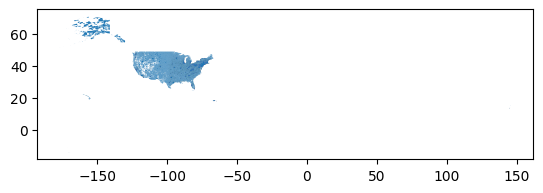

time: 25 s (started: 2024-03-06 15:53:07 +00:00)


In [43]:
# here is a plot of all the zip codes in the USA
zipcode_gdf.plot()
plt.show() # don't you miss Folium at times like this?!

All zipcodes in Connecticut start with '06'.

![zipcode map by state](https://upload.wikimedia.org/wikipedia/commons/thumb/2/24/ZIP_Code_zones.svg/1200px-ZIP_Code_zones.svg.png)

In [44]:
# we can subset this just to look at CT-related data
ct_gdf = zipcode_gdf[zipcode_gdf['ZCTA5CE10'].str.match('06')]
ct_gdf
# df1[df1['col'].str.contains(r'foo(?!$)')]

,ZCTA5CE10,GEOID10,CLASSFP10,MTFCC10,FUNCSTAT10,ALAND10,AWATER10,INTPTLAT10,INTPTLON10,geometry
2240,06524,06524,B5,G6350,S,54669006,996204,+41.4229640,-072.9941871,"POLYGON ((-73.04752 41.39594, -73.04744 41.396..."
2241,06525,06525,B5,G6350,S,48722329,971941,+41.3635379,-073.0038921,"POLYGON ((-73.04903 41.38162, -73.04893 41.383..."
2242,06604,06604,B5,G6350,S,8116657,4858982,+41.1829197,-073.2080265,"MULTIPOLYGON (((-73.22313 41.20244, -73.22293 ..."
2243,06605,06605,B5,G6350,S,6068755,1022830,+41.1615986,-073.2176223,"POLYGON ((-73.23723 41.15513, -73.23678 41.155..."
2244,06606,06606,B5,G6350,S,13697484,361561,+41.2121097,-073.2066729,"POLYGON ((-73.24409 41.22660, -73.24340 41.226..."
...,...,...,...,...,...,...,...,...,...,...
20137,06409,06409,B5,G6350,S,3503032,203413,+41.3510807,-072.4201669,"MULTIPOLYGON (((-72.43664 41.35985, -72.43621 ..."
20138,06410,06410,B5,G6350,S,84380735,723751,+41.5118273,-072.9036174,"POLYGON ((-72.96922 41.53045, -72.96879 41.531..."
20139,06412,06412,B5,G6350,S,41573118,2010913,+41.4117284,-072.4871458,"POLYGON ((-72.53878 41.42149, -72.53686 41.421..."
20140,06413,06413,B5,G6350,S,41948227,4026552,+41.2956101,-072.5291250,"POLYGON ((-72.58611 41.30919, -72.58603 41.309..."


time: 148 ms (started: 2024-03-06 15:53:32 +00:00)


283 rows... pretty close to perfect! This site says that CT has 280 zipcodes - we will call it close enough for now.


* https://www.connecticut-demographics.com/zip_codes_by_population

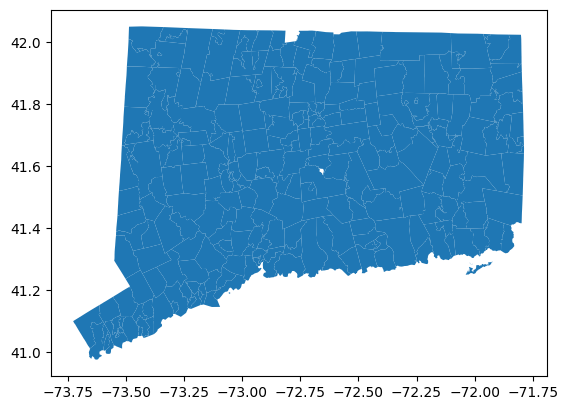

time: 367 ms (started: 2024-03-06 15:53:36 +00:00)


In [45]:
ct_gdf.plot() # it looks great!
plt.show()

In [46]:
ct_gdf.dropna(inplace=True, axis=0)
print(ct_gdf.shape)

(283, 10)
time: 10.6 ms (started: 2024-03-06 15:53:40 +00:00)


<ipython-input-46-5d0a904b4d32>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ct_gdf.dropna(inplace=True, axis=0)


How about coloring by a variable?

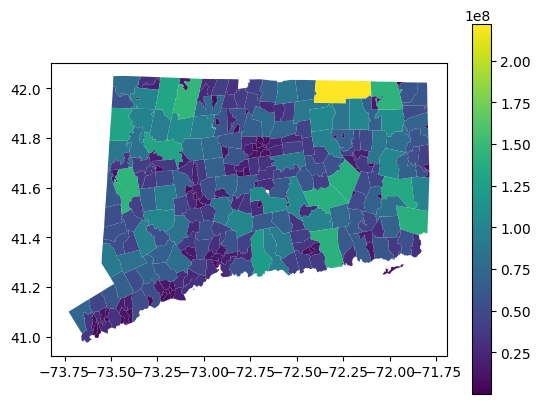

time: 486 ms (started: 2024-03-06 15:53:44 +00:00)


In [47]:
ct_gdf.plot('ALAND10', legend=True) # for example, how much land they have?
plt.show()

You could take it a step further and create a variable like Total Water/ Total Land and see if you get an interesting pattern. Left as an exercise.

# Spatial join: real estate points (lat/lon) to zipcode polygons

## Checking the CRS

In [51]:
df.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

time: 10.4 ms (started: 2024-03-06 15:55:45 +00:00)


In [52]:
ct_gdf.crs

<Geographic 2D CRS: EPSG:4269>
Name: NAD83
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: North America - onshore and offshore: Canada - Alberta; British Columbia; Manitoba; New Brunswick; Newfoundland and Labrador; Northwest Territories; Nova Scotia; Nunavut; Ontario; Prince Edward Island; Quebec; Saskatchewan; Yukon. Puerto Rico. United States (USA) - Alabama; Alaska; Arizona; Arkansas; California; Colorado; Connecticut; Delaware; Florida; Georgia; Hawaii; Idaho; Illinois; Indiana; Iowa; Kansas; Kentucky; Louisiana; Maine; Maryland; Massachusetts; Michigan; Minnesota; Mississippi; Missouri; Montana; Nebraska; Nevada; New Hampshire; New Jersey; New Mexico; New York; North Carolina; North Dakota; Ohio; Oklahoma; Oregon; Pennsylvania; Rhode Island; South Carolina; South Dakota; Tennessee; Texas; Utah; Vermont; Virginia; Washington; West Virginia; Wisconsin; Wyoming. US Virgin Islands. British Virgin Islands

time: 10 ms (started: 2024-03-06 15:55:57 +00:00)


Let's convert the points `df` to EPSG:4269.

In [53]:
df.to_crs(epsg=4269, inplace=True)
df.crs

<Geographic 2D CRS: EPSG:4269>
Name: NAD83
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: North America - onshore and offshore: Canada - Alberta; British Columbia; Manitoba; New Brunswick; Newfoundland and Labrador; Northwest Territories; Nova Scotia; Nunavut; Ontario; Prince Edward Island; Quebec; Saskatchewan; Yukon. Puerto Rico. United States (USA) - Alabama; Alaska; Arizona; Arkansas; California; Colorado; Connecticut; Delaware; Florida; Georgia; Hawaii; Idaho; Illinois; Indiana; Iowa; Kansas; Kentucky; Louisiana; Maine; Maryland; Massachusetts; Michigan; Minnesota; Mississippi; Missouri; Montana; Nebraska; Nevada; New Hampshire; New Jersey; New Mexico; New York; North Carolina; North Dakota; Ohio; Oklahoma; Oregon; Pennsylvania; Rhode Island; South Carolina; South Dakota; Tennessee; Texas; Utah; Vermont; Virginia; Washington; West Virginia; Wisconsin; Wyoming. US Virgin Islands. British Virgin Islands

time: 172 ms (started: 2024-03-06 15:57:15 +00:00)


In [54]:
# df is the point, ct_gdf is a shapefile
df_with_zips = gpd.sjoin(df, # point data (must be a gdf)
                         ct_gdf, # polygon data
                         how="inner", # points must be in the polygon
                         predicate='intersects') #

time: 80.2 ms (started: 2024-03-06 15:57:21 +00:00)


/usr/local/lib/python3.10/dist-packages/IPython/core/interactiveshell.py:3473: FutureWarning: The `op` parameter is deprecated and will be removed in a future release. Please use the `predicate` parameter instead.
  if (await self.run_code(code, result,  async_=asy)):


In [55]:
print(df_with_zips.shape)
df_with_zips.head() # see the GEOID10 column? we got it!

(731, 29)


,Unnamed: 0,ID,SerialNumber,ListYear,DateRecorded,Town,Address,AssessedValue,SaleAmount,SalesRatio,...,index_right,ZCTA5CE10,GEOID10,CLASSFP10,MTFCC10,FUNCSTAT10,ALAND10,AWATER10,INTPTLAT10,INTPTLON10
0,53330,53331,15045,2015,5/26/2016,Lisbon,26 GRAHAM TERRACE,112970,145000.0,0.779103,...,19711,06351,06351,B5,G6350,S,134731561,7122809,+41.5897876,-071.9483846
61,43605,43606,140265,2014,6/22/2015,Griswold,9-11 HIGH STREET,270130,255000.0,1.059333,...,19711,06351,06351,B5,G6350,S,134731561,7122809,+41.5897876,-071.9483846
276,53379,53380,14026,2014,4/17/2015,Lisbon,8 SYLVANDALE RD,89700,47352.0,1.894323,...,19711,06351,06351,B5,G6350,S,134731561,7122809,+41.5897876,-071.9483846
437,43433,43434,140190,2014,11/25/2014,Griswold,35 RICHARDSON HILL RD,119140,163000.0,0.730920,...,19711,06351,06351,B5,G6350,S,134731561,7122809,+41.5897876,-071.9483846
464,43291,43292,150464,2015,6/17/2016,Griswold,133 POPPLE BRIDGE ROAD,106260,73500.0,1.445714,...,19711,06351,06351,B5,G6350,S,134731561,7122809,+41.5897876,-071.9483846


time: 32.3 ms (started: 2024-03-06 15:58:31 +00:00)


## ⭐ Making a map

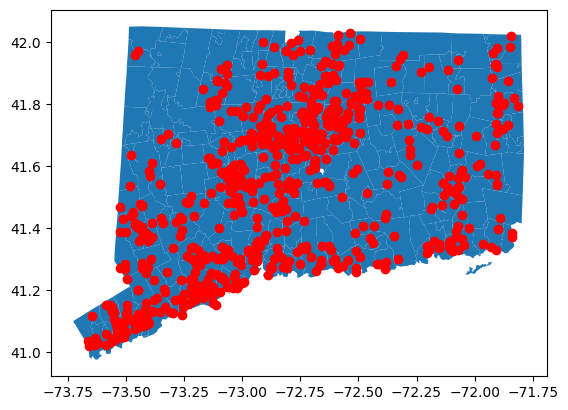

time: 655 ms (started: 2024-03-06 16:03:15 +00:00)


In [63]:
ax = ct_gdf.plot() # polygon - this goes on the bottom
df_with_zips.plot(color='red', ax=ax) # points - this gets overlayed on top
plt.show()

In [68]:
# reminder of what the columns are...
df_with_zips.columns

Index(['Unnamed: 0', 'ID', 'SerialNumber', 'ListYear', 'DateRecorded', 'Town',
       'Address', 'AssessedValue', 'SaleAmount', 'SalesRatio', 'PropertyType',
       'ResidentialType', 'oneAddress', 'location', 'point', 'latitude',
       'longitude', 'altitude', 'geometry'],
      dtype='object')

time: 3.64 ms (started: 2024-03-06 16:03:58 +00:00)


In [77]:
# convert to string so legend looks nice
df_with_zips['ListYear'] = df_with_zips['ListYear'].astype(str)

time: 6.63 ms (started: 2024-03-06 16:07:57 +00:00)


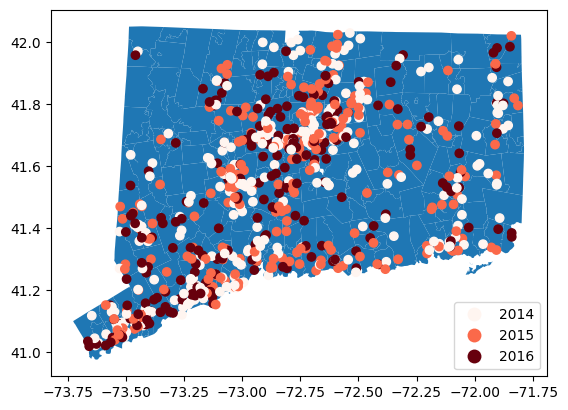

time: 694 ms (started: 2024-03-06 16:07:59 +00:00)


In [78]:
ax = ct_gdf.plot() # polygon
df_with_zips.plot(column='ListYear', cmap='Reds', ax=ax, legend=True) # points
plt.show()

Now that we have:
* our data geocoded from address to lat/lon
* spatial join to attain a zip code (`GEOID10`)

... we are able to join using zip code as a primary key! Which means we are so close to predicting house prices as a function of socioeconomic variables.

# 🦾 Can you make a map of real estate transcations per zipcode?

In [ ]:
# left to students as an exercise - email dave if you solved this!

# Save The File for Later
Let's save this as a temporary file for later.

In [ ]:
# df_with_zips.to_csv('/content/drive/MyDrive/Online Materials/Module 5: Special Topics/Week 4: Geospatial/zip_latlon_Real_Estate_Sales_2014-2016.csv')

# Resources
* Geocoding from address to lat/long
  * https://towardsdatascience.com/geocode-with-python-161ec1e62b89